In [26]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping#
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import  ConfusionMatrixDisplay, confusion_matrix, classification_report
from IPython.display import Markdown
import seaborn as sns

SEED = 42
tf.random.set_seed(SEED)

# 1. Loading and Exploring the Data

The Fashion MNIST dataset is a dataset of 28x28 grayscale images of 10 different types of clothing items.
The dataset consists of 60,000 training images and 10,000 test images.

We can load the Fashion MNIST dataset using libraries like TensorFlow, Keras


In [27]:
# Load data
from tensorflow.keras.datasets import fashion_mnist

(train_imgs, train_labels), (test_imgs, test_labels) = fashion_mnist.load_data()
print(f"Training data: images shape =  {train_imgs.shape} , labels shape = {train_labels.shape}")
print(f"Testing data: images shape = {test_imgs.shape}, labels shape = {test_labels.shape}")

# Define class names based on the Fashion MNIST dataset, we have 10 numbers of class
class_names = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

Training data: images shape =  (60000, 28, 28) , labels shape = (60000,)
Testing data: images shape = (10000, 28, 28), labels shape = (10000,)


## 1.1 Data Preprocessing

In [28]:
# Preprocess data
train_imgs = train_imgs.reshape(train_imgs.shape[0], 28, 28, 1).astype('float32')
test_imgs = test_imgs.reshape(test_imgs.shape[0], 28, 28, 1).astype('float32')

train_imgs = train_imgs / 255
test_imgs = test_imgs / 255

train_imgs, val_imgs, train_labels, val_labels = train_test_split(
    train_imgs, train_labels, test_size=0.2, random_state=42
)

print(f"After preprocess, training data: images shape =  {train_imgs.shape} , labels shape = {train_labels.shape}")
print(f"After preprocess, validation data: images shape =  {val_imgs.shape} , labels shape = {val_labels.shape}")
print(f"After preprocess, testing data: images shape = {test_imgs.shape}, labels shape = {test_labels.shape}")

# Convert train,validation and test labels to one-hot encoded vectors
train_labels = to_categorical(train_labels)
val_labels = to_categorical(val_labels)
test_labels= to_categorical(test_labels)

num_classes = test_labels.shape[1]
print(f"Numbers of classes= {num_classes}")

After preprocess, training data: images shape =  (48000, 28, 28, 1) , labels shape = (48000,)
After preprocess, validation data: images shape =  (12000, 28, 28, 1) , labels shape = (12000,)
After preprocess, testing data: images shape = (10000, 28, 28, 1), labels shape = (10000,)
Numbers of classes= 10


# 2. Training the Neural Network

Training a Neural Network (NN) requires 4 steps:
1.   Build the architecture
2.   Compile the model
3.   Train the model
4.   Evaluating the model

I plan to try two different models to get the best result with **less validation loss** and **high validation accuracy**. They are
1.   `Simple Feedforward Neural Network`
2.   `Basic CNN`


First of all, I create necessary helper functions for the requires steps in training a neural network.

## 2.1 Building the Model Architecture

In [29]:
def build_model(model):
  print(f"Model : {model}")
  print(f"{model.summary()}")

  # Compile the model
  model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

  return model

## 2.2 Training the Model

In [30]:
def train_model(model,train_imgs,train_labels,val_imgs,val_labels):
  # We choose arbitrary cutoff , epochs 10 and batch size 200. We use early stopping to prevent overfitting.
  early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

  model_history= model.fit(train_imgs, train_labels,
                          epochs=10,  batch_size=200, verbose=2 ,
                          validation_data=(val_imgs, val_labels), callbacks=[early_stopping])

  return model_history

## 2.3 Evaluating the Model

In [31]:
def evaluate_model(model, test_imgs, test_labels):
  test_loss, test_accuracy= model.evaluate(test_imgs, test_labels, batch_size=100, verbose=0)
  print(f"{model.name} : Test Loss= {test_loss}, Test Accuracy= {test_accuracy}")

  return test_loss, test_accuracy

In [32]:
def plot_metrics(model, history):
  # Plot the accuracy values of training & validation dataset
  plt.figure(figsize=(6, 4))
  plt.plot(history.history['accuracy'])
  plt.plot(history.history['val_accuracy'])
  plt.title(f"Model Accuracy ({model.name})")
  plt.xlabel('Epoch')
  plt.ylabel('Accuracy')
  plt.legend(['Train', 'Validation'])
  plt.show()

  # Plot the loss values of training & validation dataset
  plt.figure(figsize=(6, 4))
  plt.plot(history.history['loss'])
  plt.plot(history.history['val_loss'])
  plt.title(f"Model Loss ({model.name})")
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.legend(['Train', 'Validation'])
  plt.show()

# 3. Prediction

In [33]:
def predict_and_visualize(model, test_imgs):
  # Now we make predictions on the test data by using trained model:
  predictions = model.predict(test_imgs)
  y_pred_classes = np.argmax(predictions, axis=1)

  # Visualize some predictions to see how well the model is performing:
  plt.figure(figsize=(15, 15))
  for i in range(25):
      plt.subplot(10, 10, i + 1)
      plt.xticks([])
      plt.yticks([])
      plt.grid(False)
      plt.imshow(test_imgs[i], cmap=plt.cm.binary)
      predicted_label = np.argmax(predictions[i])
      true_label = np.argmax(test_labels[i])
      color = 'blue' if predicted_label == true_label else 'red'
      plt.xlabel(f"{class_names[predicted_label]}", color=color)
  plt.show()

  return y_pred_classes

# 4. Analysis the Model Performance

In [34]:
def compute_matrix(model_name, test_labels,  y_pred_classes):
  # Compute the confusion matrix
  y_true_classes = np.argmax(test_labels, axis=1) # Extract true classes from one-hot encoding
  cmatx = confusion_matrix(y_true_classes, y_pred_classes) # Compare true and predicted classes

  # Plot the confusion matrix using a heatmap
  plt.figure(figsize=(10, 8))
  sns.heatmap(cmatx, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
  plt.xlabel('Predicted Label')
  plt.ylabel('True Label')
  plt.title(f"Confusion Matrix (Model {model_name})")
  plt.show()

  return y_true_classes, cmatx

# 5. Implementing the Neural Network

## 5.1 Base Model - Simple Feedforward Neural Network

In [35]:
# Base Model : Simple Feedforward Neural Network
model_NN = Sequential([
    Flatten(input_shape=(28, 28,1)),
    Dense(128, activation='relu'),
    Dense(num_classes, activation='softmax')  # Output layer for 10 classes
],name="feedforward_nn")


# Build the model
build_model(model_NN)

# Train the model
history_NN = train_model(model_NN, train_imgs, train_labels, val_imgs, val_labels)

Model : <Sequential name=feedforward_nn, built=True>


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "feedforward_nn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/10
240/240 - 6s - 26ms/step - accuracy: 0.7880 - loss: 0.6271 - val_accuracy: 0.8404 - val_loss: 0.4695
Epoch 2/10
240/240 - 4s - 18ms/step - accuracy: 0.8477 - loss: 0.4388 - val_accuracy: 0.8550 - val_loss: 0.4178
Epoch 3/10
240/240 - 2s - 8ms/step - accuracy: 0.8606 - loss: 0.3970 - val_accuracy: 0.8590 - val_loss: 0.3990
Epoch 4/10
240/240 - 2s - 7ms/step - accuracy: 0.8692 - loss: 0.3703 - val_accuracy: 0.8640 - val_loss: 0.3858
Epoch 5/10
240/240 - 2s - 8ms/step - accuracy: 0.8749 - loss: 0.3503 - val_accuracy: 0.8643 - val_loss: 0.3810
Epoch 6/10
240/240 - 2s - 7ms/step - accuracy: 0.8810 - loss: 0.3335 - val_accuracy: 0.8648 - val_loss: 0.3786
Epoch 7/10
240/240 - 2s - 7ms/step - accuracy: 0.8853 - loss: 0.3191 - val_accuracy: 0.8695 - val_loss: 0.3698
Epoch 8/10
240/240 - 2s - 7ms/step - accuracy: 0.8907 - loss: 0.3062 - val_accuracy: 0.8700 - val_loss: 0.3664
Epoch 9/10
240/240 - 3s - 11ms/step - accuracy: 0.8931 - loss: 0.2953 - val_accuracy: 0.8718 - val_loss: 

In [36]:
# Evaluate the model
test_loss_NN, test_accuracy_NN = evaluate_model(model_NN, test_imgs, test_labels)

Markdown(f"Our test loss is around **{round(test_loss_NN,2) * 100}%** and accuracy is around **{round(test_accuracy_NN,2)*100}%** for this neural network with 10 epochs.\nThe result is not so good as test loss is a bit high.")

feedforward_nn : Test Loss= 0.38535526394844055, Test Accuracy= 0.8646000027656555


Our test loss is around **39.0%** and accuracy is around **86.0%** for this neural network with 10 epochs.
The result is not so good as test loss is a bit high.

We plot history data of Model Accuracy and Model Loss along with the Epoch.


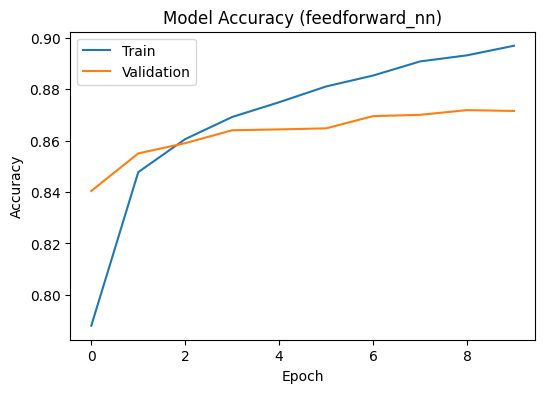

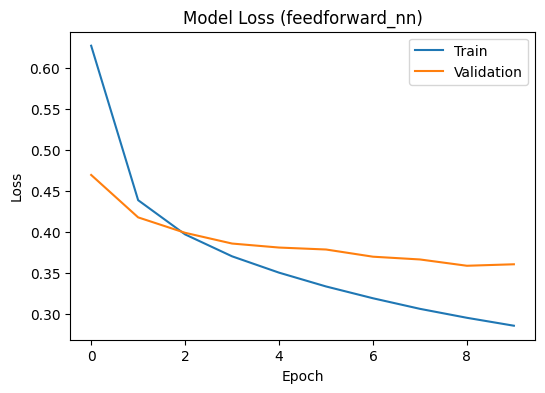

In [37]:
# Visualise Model Accuracy and Loss
plot_metrics(model_NN, history_NN)

After evaluating the model, we do the prediction task on the test data.


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


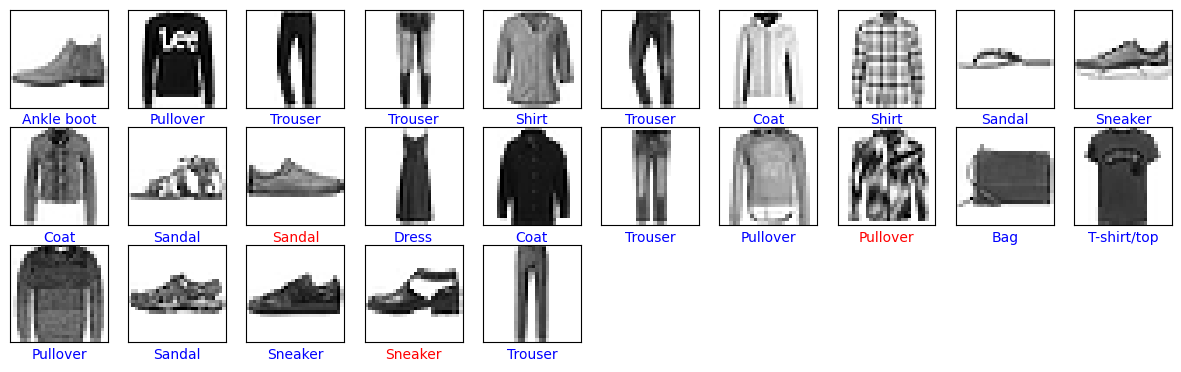

In [38]:
# Predict test set
y_pred_classes_NN = predict_and_visualize(model_NN, test_imgs )


The above images are the outcome of our model predicted labels. Red color indicate model predict wrongly.


We plot heatmap to analysis possible errors generated by our model .


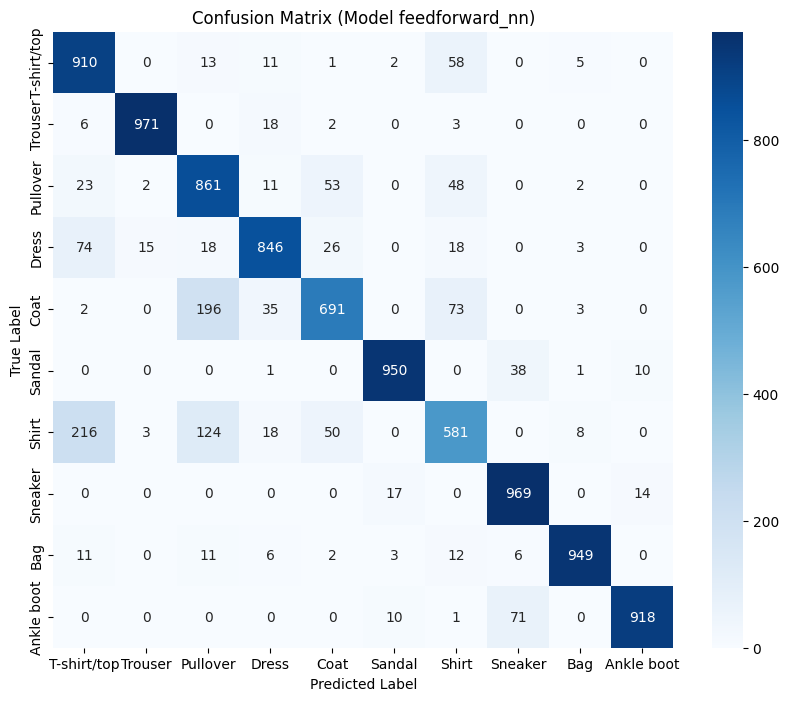

In [39]:
# Analysis the model
y_true_classes_NN, cmatx_NN = compute_matrix(model_NN.name,test_labels, y_pred_classes_NN)


In [40]:
df_cmatx_NN = pd.DataFrame(cmatx_NN, index=class_names, columns=class_names)
shirt_shirt = df_cmatx_NN.loc['Shirt','Shirt']
shirt_tshirt = df_cmatx_NN.loc['Shirt','T-shirt/top']
shirt_coat = df_cmatx_NN.loc['Shirt','Coat']
shirt_pullover = df_cmatx_NN.loc['Shirt','Pullover']
shirt_miss_rate = ((1000 - shirt_shirt) / 1000 ) * 100

Markdown(f"As we can observe above confusion matrix of simple feedforward neural network, it achieves reasonable performance on visually distinct classes.\nBut **Shirt** is the **most confused class** and giving us **high miss rate {shirt_miss_rate}%**, only {shirt_shirt} out of 1000 is correctly predicted by our model. Here are some of errors on its misclassification.\n* {shirt_tshirt} misclassified as T-shirt/top\n* {shirt_coat} misclassified as Coat\n * {shirt_pullover} misclassified as Pullover")

As we can observe above confusion matrix of simple feedforward neural network, it achieves reasonable performance on visually distinct classes.
But **Shirt** is the **most confused class** and giving us **high miss rate 41.9%**, only 581 out of 1000 is correctly predicted by our model. Here are some of errors on its misclassification.
* 216 misclassified as T-shirt/top
* 50 misclassified as Coat
 * 124 misclassified as Pullover

## 5.2 Compare Model - Convolutional Neural Networks (CNNs)

In [41]:
# Compare Model : Convolutional Neural Networks (CNNs)
# We use same set of preprocessed data.
model_CNN = Sequential([
        Conv2D(32, (3, 3), activation='relu',
               input_shape=(28, 28, 1)),
        MaxPooling2D((2, 2)),
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        Conv2D(64, (3, 3), activation='relu'),
        Flatten(),
        Dense(64, activation='relu'),
        Dense(10, activation='softmax')
], name="basic_cnn")

# Build the model
build_model(model_CNN)

# Train the model
history_CNN = train_model(model_CNN, train_imgs, train_labels, val_imgs, val_labels)

Model : <Sequential name=basic_cnn, built=True>


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "basic_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,322 (364.54 KB)

 Trainable params: 93,322 (364.54 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/10
240/240 - 42s - 177ms/step - accuracy: 0.7323 - loss: 0.7224 - val_accuracy: 0.8338 - val_loss: 0.4660
Epoch 2/10
240/240 - 41s - 173ms/step - accuracy: 0.8483 - loss: 0.4156 - val_accuracy: 0.8673 - val_loss: 0.3763
Epoch 3/10
240/240 - 82s - 340ms/step - accuracy: 0.8714 - loss: 0.3545 - val_accuracy: 0.8720 - val_loss: 0.3523
Epoch 4/10
240/240 - 41s - 173ms/step - accuracy: 0.8838 - loss: 0.3200 - val_accuracy: 0.8813 - val_loss: 0.3232
Epoch 5/10
240/240 - 41s - 169ms/step - accuracy: 0.8931 - loss: 0.2973 - val_accuracy: 0.8846 - val_loss: 0.3172
Epoch 6/10
240/240 - 41s - 171ms/step - accuracy: 0.9003 - loss: 0.2788 - val_accuracy: 0.8863 - val_loss: 0.3106
Epoch 7/10
240/240 - 40s - 168ms/step - accuracy: 0.9054 - loss: 0.2618 - val_accuracy: 0.8899 - val_loss: 0.3016
Epoch 8/10
240/240 - 41s - 171ms/step - accuracy: 0.9112 - loss: 0.2470 - val_accuracy: 0.8937 - val_loss: 0.2951
Epoch 9/10
240/240 - 41s - 169ms/step - accuracy: 0.9170 - loss: 0.2326 - val_accur

In [42]:
# Evaluate the model
test_loss_CNN, test_accuracy_CNN = evaluate_model(model_CNN, test_imgs, test_labels)

Markdown(f"Compared to previous model using Simple Feedforward Neural Network, now our test loss decreases to **{round(test_loss_CNN,2) * 100}%** from **{round(test_loss_NN,2) * 100}%** and accuracy increase to **{round(test_accuracy_CNN,2) * 100}%** from **{round(test_accuracy_NN,2) * 100}%**.")

basic_cnn : Test Loss= 0.29850974678993225, Test Accuracy= 0.89410001039505


Compared to previous model using Simple Feedforward Neural Network, now our test loss decreases to **30.0%** from **39.0%** and accuracy increase to **89.0%** from **86.0%**.

We plot history data of Model Accuracy and Model Loss along with the Epoch.

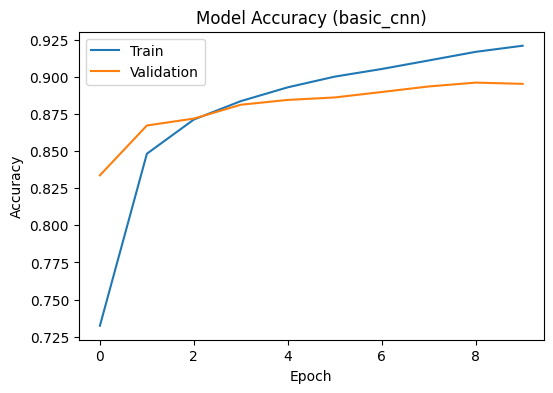

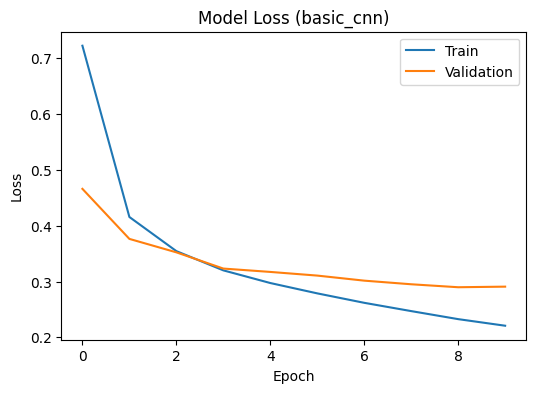

In [43]:
# Visualise Model Accuracy and Loss
plot_metrics(model_CNN, history_CNN)

Compared to Simple Feedforward neural network model, by using this CNN model, the **gap between training and validation accuracy** becomes **small** and the **gap between training and validation loss** also becomes **small**.


After evaluating the model, we do the prediction task on the test data


313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step


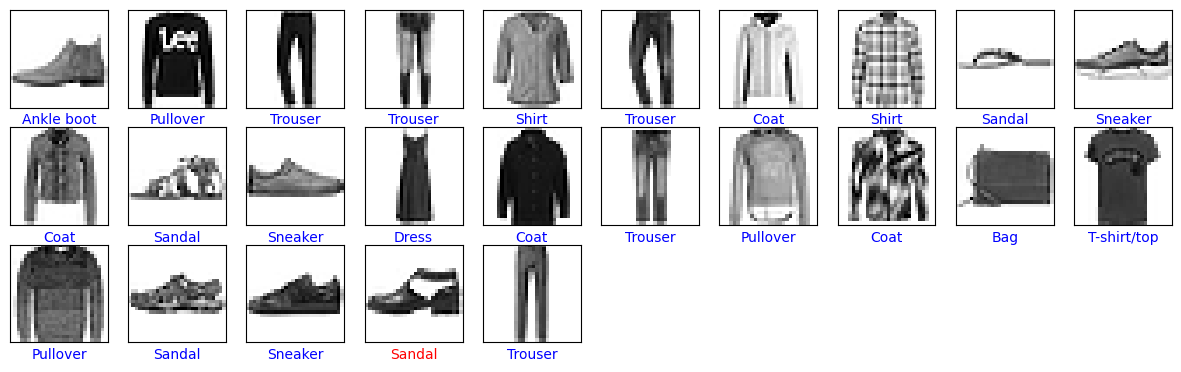

In [44]:
# Predict test set
y_pred_classes_CNN = predict_and_visualize(model_CNN, test_imgs )

The above images are the outcome of our model predicted labels. Red color indicate model predict wrongly.

We plot heatmap to analysis possible errors generated by our model .

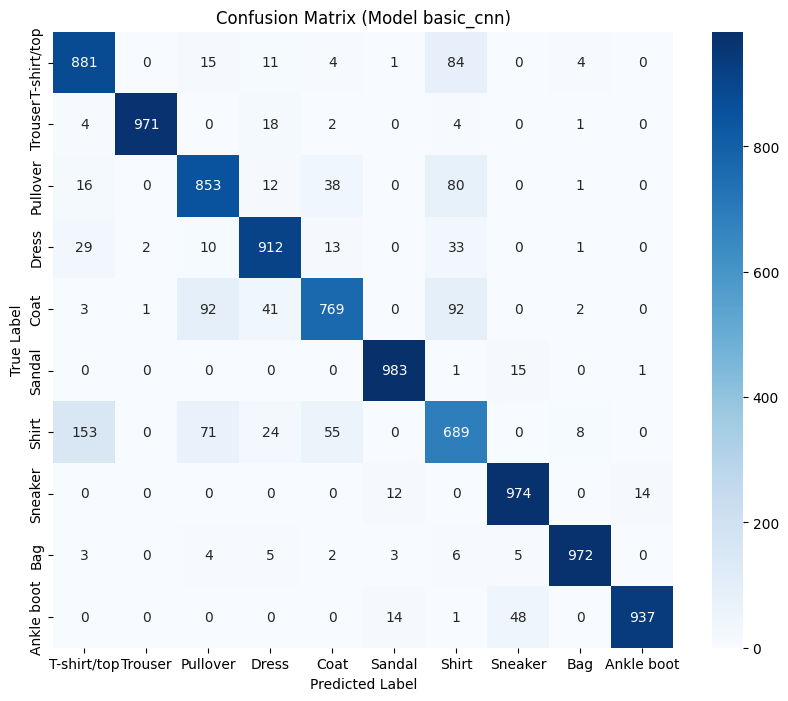

In [45]:
# Analysis the model
y_true_classes_CNN, cmatx_CNN = compute_matrix(model_CNN.name, test_labels, y_pred_classes_CNN)


In [46]:
df_cmatx_CNN = pd.DataFrame(cmatx_CNN, index=class_names, columns=class_names)
shirt_shirt_C = df_cmatx_CNN.loc['Shirt','Shirt']
shirt_tshirt_C = df_cmatx_CNN.loc['Shirt','T-shirt/top']
shirt_coat_C = df_cmatx_CNN.loc['Shirt','Coat']
shirt_pullover_C = df_cmatx_CNN.loc['Shirt','Pullover']
shirt_miss_rate_C = round(((1000 - shirt_shirt_C) / 1000 ) * 100,2)

trouser_C =  df_cmatx_CNN.loc['Trouser','Trouser']
sandal_C =  df_cmatx_CNN.loc['Sandal','Sandal']
bag_C =  df_cmatx_CNN.loc['Bag','Bag']

Markdown(f"CNN's overall **performance** is **strong**.\n\nIn our confusion matrix, the diagonal line is **dominant across all 10 classes**, which means the model is largely doing the right thing.\n\nClasses like **Trouser ({trouser_C})**, **Sandal ({sandal_C})**, and **Bag ({bag_C})** are nearly perfect, they show us visually distinct items with little overlap with other categories.\n\nBut **Shirt** is the weakest class with a wide margin. Out of 1000 actual Shirt samples, only **{shirt_shirt_C}** were correctly predicted by our model.\nWe can break down its downside as:\n* {shirt_tshirt_C} misclassified as T-shirt/top\n* {shirt_coat_C} misclassified as Coat\n * {shirt_pullover_C} misclassified as Pullover \n\nSo as the conclusion, miss rate **{shirt_miss_rate_C}%** is quite obvious and we should consider any possible improvements to address this issue.")

CNN's overall **performance** is **strong**.

In our confusion matrix, the diagonal line is **dominant across all 10 classes**, which means the model is largely doing the right thing.

Classes like **Trouser (971)**, **Sandal (983)**, and **Bag (972)** are nearly perfect, they show us visually distinct items with little overlap with other categories.

But **Shirt** is the weakest class with a wide margin. Out of 1000 actual Shirt samples, only **689** were correctly predicted by our model.
We can break down its downside as:
* 153 misclassified as T-shirt/top
* 55 misclassified as Coat
 * 71 misclassified as Pullover 

So as the conclusion, miss rate **31.1%** is quite obvious and we should consider any possible improvements to address this issue.

# 6. Results

After we analysis confusion matrix on both neural networks, I decided to continue further evaluation to obtain **precision** and **recall** value of the two neural networks.


In [47]:
# Simple Feedforward - Precion and Recall
print(f"Classification Report : \n{classification_report(y_true_classes_NN, y_pred_classes_NN, target_names=class_names)}")

clss_rpt_dict_NN = classification_report(y_true_classes_NN, y_pred_classes_NN, target_names=class_names, output_dict=True)
df_metrics_NN  = pd.DataFrame(clss_rpt_dict_NN).transpose()
df_precision_recall_NN = df_metrics_NN[['precision', 'recall']]
print(f"Simple Feedforward - Precion and Recall\n{df_precision_recall_NN}")

Classification Report : 
              precision    recall  f1-score   support

 T-shirt/top       0.73      0.91      0.81      1000
     Trouser       0.98      0.97      0.98      1000
    Pullover       0.70      0.86      0.77      1000
       Dress       0.89      0.85      0.87      1000
        Coat       0.84      0.69      0.76      1000
      Sandal       0.97      0.95      0.96      1000
       Shirt       0.73      0.58      0.65      1000
     Sneaker       0.89      0.97      0.93      1000
         Bag       0.98      0.95      0.96      1000
  Ankle boot       0.97      0.92      0.95      1000

    accuracy                           0.86     10000
   macro avg       0.87      0.86      0.86     10000
weighted avg       0.87      0.86      0.86     10000

Simple Feedforward - Precion and Recall
              precision  recall
T-shirt/top    0.732689  0.9100
Trouser        0.979818  0.9710
Pullover       0.704007  0.8610
Dress          0.894292  0.8460
Coat           0

In [48]:
# CNN - Precion and Recall
print(f"Classification Report : \n{classification_report(y_true_classes_CNN, y_pred_classes_CNN, target_names=class_names)}")

clss_rpt_dict_CNN = classification_report(y_true_classes_CNN, y_pred_classes_CNN, target_names=class_names, output_dict=True)
df_metrics_CNN  = pd.DataFrame(clss_rpt_dict_CNN).transpose()
df_precision_recall_CNN = df_metrics_CNN[['precision', 'recall']]
print(f"CNN - Precision and Recall\n{df_precision_recall_CNN}")

Classification Report : 
              precision    recall  f1-score   support

 T-shirt/top       0.81      0.88      0.84      1000
     Trouser       1.00      0.97      0.98      1000
    Pullover       0.82      0.85      0.83      1000
       Dress       0.89      0.91      0.90      1000
        Coat       0.87      0.77      0.82      1000
      Sandal       0.97      0.98      0.98      1000
       Shirt       0.70      0.69      0.69      1000
     Sneaker       0.93      0.97      0.95      1000
         Bag       0.98      0.97      0.98      1000
  Ankle boot       0.98      0.94      0.96      1000

    accuracy                           0.89     10000
   macro avg       0.90      0.89      0.89     10000
weighted avg       0.90      0.89      0.89     10000

CNN - Precision and Recall
              precision  recall
T-shirt/top    0.808999  0.8810
Trouser        0.996920  0.9710
Pullover       0.816268  0.8530
Dress          0.891496  0.9120
Coat           0.870895  0.76

## 6.1 Compare Results
As we can see from the charts below, the **basic convolutional neural netwo**rk performs very well in both metrics compared with the simple feedforward neural network, offering a **stronger balance between recall and precision**.
And also according to confusion matrix, in simple feedforward neural network, most of the classes show lighter diagonal cells compared to the CNN matrix which tells us feedforward is weaker overall performance.

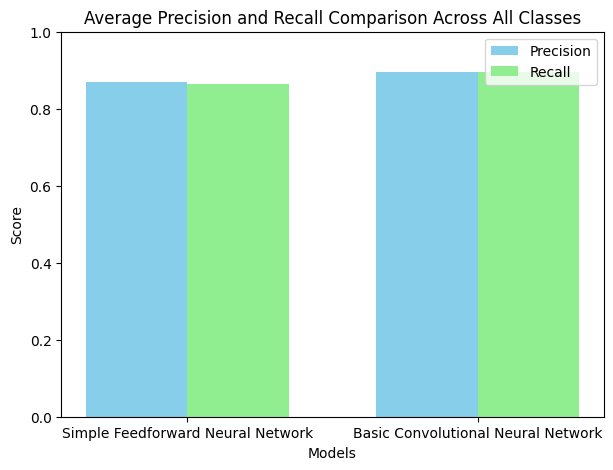

In [49]:
models = ['Simple Feedforward Neural Network', 'Basic Convolutional Neural Network']

# Extract macro average precision and recall for each model
precision_NN = df_precision_recall_NN.loc['macro avg', 'precision']
precision_CNN = df_precision_recall_CNN.loc['macro avg', 'precision']
recall_NN = df_precision_recall_NN.loc['macro avg', 'recall']
recall_CNN = df_precision_recall_CNN.loc['macro avg', 'recall']

# Create lists for plotting
precision_to_plot = [precision_NN, precision_CNN]
recall_to_plot = [recall_NN, recall_CNN]

bar_width = 0.35
x = range(len(models))

plt.figure(figsize=(7,5))
plt.bar(x, precision_to_plot, width=bar_width, label='Precision', color='skyblue')
plt.bar([i + bar_width for i in x], recall_to_plot, width=bar_width, label='Recall', color='lightgreen')

plt.xlabel('Models')
plt.ylabel('Score')
plt.title('Average Precision and Recall Comparison Across All Classes')
plt.xticks([i + bar_width/2 for i in x], models)
plt.ylim(0, 1)
plt.legend()
plt.show()

# 7. Conclusion

Basically, both models work well and most classes handle well. But their performance degrade sharply on garments with similar silhouettes.

We can observe below recall comparison table, **Shirt** is the worst result across both models.
And '**Coat**' and '**Pullover**' are the heavy confusion class because of collar shape and sleeve length or fabric texture at low resolution. This fact telling us that the gap is most severe on classes that require **texture** and **spatial pattern recognition**. **CNNs** mostly capture local spatial patterns, its dense layers treat every pixel independently.

In conclusion, we can implement this kind of image classifier aligns with the business requirements with a certain threshold level apply to the outstanding neural network here which is Convolutional neural network.

In my next notebook, I plan to create realtime image classifier with FastAPI and Streamlit app to get more responsive and intuitiated result.

In [50]:
problem_classes = ['Shirt', 'Coat','Pullover', 'Sandal', 'Sneaker', 'Trouser']
Feedforward_recall = [df_precision_recall_NN.loc[p_class,'recall'] for p_class in problem_classes]
CNN_recall = [df_precision_recall_CNN.loc[p_class,'recall'] for p_class in problem_classes]
diff =  ( np.array(Feedforward_recall) - np.array(CNN_recall) ) * 100

df_problem_class_recall = pd.DataFrame({'class':problem_classes, 'Feedforward_recall(%)':[r * 100 for r in Feedforward_recall],'CNN_recall(%)':[r * 100 for r in CNN_recall],'Difference(%)':diff })
print(df_problem_class_recall.to_string())


      class  Feedforward_recall(%)  CNN_recall(%)  Difference(%)
0     Shirt                   58.1           68.9          -10.8
1      Coat                   69.1           76.9           -7.8
2  Pullover                   86.1           85.3            0.8
3    Sandal                   95.0           98.3           -3.3
4   Sneaker                   96.9           97.4           -0.5
5   Trouser                   97.1           97.1            0.0
